In [114]:
!git clone https://github.com/ISorokos/SafeML.git

fatal: destination path 'SafeML' already exists and is not an empty directory.


In [ ]:
import sys

sys.path.insert(1, r'c:\Users\vinay t\OneDrive\Desktop\MAIN PROJ\SafeML\Implementation_in_Python')

from CVM_Distance import CVM_Dist as Cramer_Von_Mises_Dist
from Anderson_Darling_Distance import Anderson_Darling_Dist
from Kolmogorov_Smirnov_Distance import Kolmogorov_Smirnov_Dist
from KuiperDistance import Kuiper_Dist
from WassersteinDistance import Wasserstein_Dist
from DTS_Distance import DTS_Dist


In [116]:
%matplotlib inline

!pip install scikit-plot

import os
import sys
import warnings
import scipy

from numpy import interp

scipy.interp = interp

nb_dir = os.path.split(os.getcwd())[0]

if nb_dir not in sys.path:
    sys.path.append(nb_dir)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sklearn
import scikitplot as skplt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from scikitplot.metrics import plot_confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings('ignore')

In [117]:
def clean_dataset(df):
    assert isinstance(df, pd.DataFrame), "df needs to be a pd.DataFrame"
    df.dropna(inplace=True)
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(axis=1)
    return df[indices_to_keep]

In [118]:
def get_PCA_feature_names(num_of_pca_components):
    feature_names = []
    for i in range(num_of_pca_components):    
        feature_names.append(f"Principal component {i+1}")
    return feature_names

In [119]:
def train_model_predict(model, model_name, X, y, skf):
    for train_index, test_index in skf.split(X, y): # 1)
        X_train, X_test = X.iloc[train_index], X.iloc[test_index] # 2)
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        reshaped_y_train = np.asarray(y_train).reshape(-1, 1) # 3)
        reshaped_y_test = np.asarray(y_test).reshape(-1, 1)
        
    model.fit(X_train, reshaped_y_train.ravel()) # 4)
    pred_y = model.predict(X_test) # 5)
    score = classification_report(reshaped_y_test, pred_y) # 6)
    print('Classification report: \n', score, '\n')
    plot_confusion_matrix(reshaped_y_test, pred_y, title='Confusion Matrix for {}'.format(model_name))
        
    return accuracy_score(reshaped_y_test, pred_y), X_train, X_test, y_train, pred_y

In [120]:
def get_shuffled_stratifiedKFold_train_test_split(X, y):

    skf = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=42
    )

    for train_index, test_index in skf.split(X, y):

        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

    return X_train, X_test, y_train, y_test

In [121]:
def train_and_predict_Neural_Network_MLP_model(X_train, X_test, y_train, y_test):
    # Instantiating new Neural Network classifier and setting Hyperparameters
    Neural_Net_model = MLPClassifier(hidden_layer_sizes=(10,), activation='relu',
                                    solver='adam', alpha=0.01, batch_size='auto',
                                    learning_rate='adaptive', learning_rate_init=0.1,
                                    max_iter=2)
    
    # Fitting the model is synonymous to training the model. Convert the labels to a NumPy array before raveling.
    Neural_Net_model.fit(X_train, y_train.to_numpy().ravel())
    
    # Using the model to predict the label/ classes, based upon X_test data only. This is the model's answers.
    pred_y = Neural_Net_model.predict(X_test) 
    
    # Returning model answers and the accuracy of the model i.e. how well it predicts the answers.
    return pred_y, accuracy_score(y_test, pred_y)


In [ ]:
def train_and_predict_Neural_Network_MLP_model(
    X_train,
    X_test,
    y_train,
    y_test
):

    Neural_Net_model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation='relu',
        solver='adam',
        alpha=0.01,
        batch_size='auto',
        learning_rate='adaptive',
        learning_rate_init=0.1,
        max_iter=100,
        early_stopping=True,
        n_iter_no_change=5,
        random_state=42
    )

    Neural_Net_model.fit(
        X_train,
        y_train.to_numpy().ravel()
    )

    pred_y = Neural_Net_model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        pred_y
    )

    return pred_y, accuracy


In [123]:
def get_statistical_dist_measures_for_class_result(
    accuracy,
    X_train_L,
    X_test_L
):
    """
    Computes multiple statistical distance measures between
    training and testing datasets feature-wise.

    Parameters
    ----------
    accuracy : float
        Classification accuracy of the ML model.

    X_train_L : pandas.DataFrame
        Training feature dataset.

    X_test_L : pandas.DataFrame
        Testing feature dataset.

    Returns
    -------
    dict
        Dictionary containing:
        - Accuracy
        - Anderson Darling Distance
        - Cramer Von Mises Distance
        - DTS Distance
        - Kolmogorov Smirnov Distance
        - Kuiper Distance
        - Wasserstein Distance
    """

    num_of_features = len(X_train_L.columns)

    CVM_distances = np.zeros(num_of_features)
    Anderson_Darling_distances = np.zeros(num_of_features)
    Kolmogorov_Smirnov_distances = np.zeros(num_of_features)
    Kuiper_distances = np.zeros(num_of_features)
    Wasserstein_distances = np.zeros(num_of_features)
    DTS_distances = np.zeros(num_of_features)

    for i in range(num_of_features):

        train_feature = X_train_L.iloc[:, i]
        test_feature = X_test_L.iloc[:, i]

        CVM_distances[i] = Cramer_Von_Mises_Dist(
            train_feature,
            test_feature
        )

        Anderson_Darling_distances[i] = Anderson_Darling_Dist(
            train_feature,
            test_feature
        )

        Kolmogorov_Smirnov_distances[i] = Kolmogorov_Smirnov_Dist(
            train_feature,
            test_feature
        )

        Kuiper_distances[i] = Kuiper_Dist(
            train_feature,
            test_feature
        )

        Wasserstein_distances[i] = Wasserstein_Dist(
            train_feature,
            test_feature
        )

        DTS_distances[i] = DTS_Dist(
            train_feature,
            test_feature
        )

    CVM_distance = np.mean(
        CVM_distances,
        dtype=np.float64
    )

    Anderson_Darling_distance = np.mean(
        Anderson_Darling_distances,
        dtype=np.float64
    )

    Kolmogorov_Smirnov_distance = np.mean(
        Kolmogorov_Smirnov_distances,
        dtype=np.float64
    )

    Kuiper_distance = np.mean(
        Kuiper_distances,
        dtype=np.float64
    )

    Wasserstein_distance = np.mean(
        Wasserstein_distances,
        dtype=np.float64
    )

    DTS_distance = np.mean(
        DTS_distances,
        dtype=np.float64
    )

    return {
        'Accuracy': accuracy,
        'Anderson_Darling_dist': Anderson_Darling_distance,
        'CVM_dist': CVM_distance,
        'DTS_dist': DTS_distance,
        'Kolmogorov_Smirnov_dist': Kolmogorov_Smirnov_distance,
        'Kuiper_dist': Kuiper_distance,
        'Wasserstein_dist': Wasserstein_distance
    }

In [124]:
def get_X_train_and_test_data_for_given_label(
    labels,
    label_index,
    pred_y,
    X_train,
    X_test,
    y_train,
    y_test
):
    """
    Extracts training and testing samples for a specific class label.

    Parameters
    ----------
    labels : list
        List of all class labels.

    label_index : int
        Index of the target label.

    pred_y : array-like
        Predicted labels from the model.

    X_train : pandas.DataFrame
        Training feature dataset.

    X_test : pandas.DataFrame
        Testing feature dataset.

    y_train : pandas.Series
        Actual training labels.

    y_test : pandas.Series
        Actual testing labels.

    Returns
    -------
    tuple
        Returns:
        - X_train_loc_for_label
        - X_test_loc_for_label
    """

    target_label = labels[label_index]

    X_train_loc_for_label = X_train.loc[
        y_train == target_label
    ]

    X_test_loc_for_label = X_test.loc[
        pred_y == target_label
    ]

    return (
        X_train_loc_for_label,
        X_test_loc_for_label
    )

In [125]:
def get_concatenated_results_holding_all_classes_results(
    number_of_classes,
    result_dataframes
):

    dataframes = []

    for i in range(number_of_classes):

        class_name = f'class{i}'

        dataframe = result_dataframes[i].assign(
            dataset=class_name
        )

        dataframes.append(dataframe)

    concatenated = pd.concat(
        dataframes,
        ignore_index=True
    )

    return concatenated

In [ ]:
dimensions_num_for_PCA = 7

number_of_permutations = 1  # reduced for notebook execution

num_of_splits_for_skf = 10

seed_val = 1

num_of_statistical_dist_measures = 6


In [127]:
Friday_Morning_Data = pd.read_csv(
    r'C:\Users\vinay t\OneDrive\Desktop\MAIN PROJ\SafeML\Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
)

df = Friday_Morning_Data.copy()

print(
    "Datatype of Dataframe i.e. Pandas Dataframe:",
    type(df)
)

print(
    "Datatype of Column i.e. Pandas Series:",
    type(df.iloc[:, 1])
)

df.head()

Datatype of Dataframe i.e. Pandas Dataframe: <class 'pandas.DataFrame'>
Datatype of Column i.e. Pandas Series: <class 'pandas.Series'>


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [128]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
df.head()

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [129]:
df.dtypes

destination_port                 int64
flow_duration                    int64
total_fwd_packets                int64
total_backward_packets           int64
total_length_of_fwd_packets      int64
                                ...   
idle_mean                      float64
idle_std                       float64
idle_max                         int64
idle_min                         int64
label                              str
Length: 79, dtype: object

In [130]:
df_cleaned = df.copy()
df_cleaned = clean_dataset(df_cleaned) 
df_cleaned

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286462,443,196135,49,57,1331,105841,570,0,27.163265,108.067176,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286463,443,378424,49,59,1325,104393,570,0,27.040816,108.095051,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286464,443,161800,70,103,1427,215903,570,0,20.385714,90.746389,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286465,443,142864,50,62,1331,110185,570,0,26.620000,107.027727,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [131]:
df_cleaned = df_cleaned.reset_index()

df_cleaned.drop(
    'index',
    axis=1,
    inplace=True
)

df_cleaned

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min,label
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,32,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286091,443,196135,49,57,1331,105841,570,0,27.163265,108.067176,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286092,443,378424,49,59,1325,104393,570,0,27.040816,108.095051,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286093,443,161800,70,103,1427,215903,570,0,20.385714,90.746389,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
286094,443,142864,50,62,1331,110185,570,0,26.620000,107.027727,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [132]:
df.columns.tolist()

['destination_port',
 'flow_duration',
 'total_fwd_packets',
 'total_backward_packets',
 'total_length_of_fwd_packets',
 'total_length_of_bwd_packets',
 'fwd_packet_length_max',
 'fwd_packet_length_min',
 'fwd_packet_length_mean',
 'fwd_packet_length_std',
 'bwd_packet_length_max',
 'bwd_packet_length_min',
 'bwd_packet_length_mean',
 'bwd_packet_length_std',
 'flow_bytes/s',
 'flow_packets/s',
 'flow_iat_mean',
 'flow_iat_std',
 'flow_iat_max',
 'flow_iat_min',
 'fwd_iat_total',
 'fwd_iat_mean',
 'fwd_iat_std',
 'fwd_iat_max',
 'fwd_iat_min',
 'bwd_iat_total',
 'bwd_iat_mean',
 'bwd_iat_std',
 'bwd_iat_max',
 'bwd_iat_min',
 'fwd_psh_flags',
 'bwd_psh_flags',
 'fwd_urg_flags',
 'bwd_urg_flags',
 'fwd_header_length',
 'bwd_header_length',
 'fwd_packets/s',
 'bwd_packets/s',
 'min_packet_length',
 'max_packet_length',
 'packet_length_mean',
 'packet_length_std',
 'packet_length_variance',
 'fin_flag_count',
 'syn_flag_count',
 'rst_flag_count',
 'psh_flag_count',
 'ack_flag_count',
 'ur

In [133]:
df_labels = df_cleaned['label']

df_labels.unique()


<ArrowStringArray>
['BENIGN', 'PortScan']
Length: 2, dtype: str

In [134]:
df_no_labels = df_cleaned.drop(
    'label',
    axis=1,
    inplace=False
)

df_features = df_no_labels.columns.tolist()

df_no_labels

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min
0,22,1266342,41,44,2664,6954,456,0,64.975610,109.864573,...,24,32,0.0,0.0,0,0,0.0,0.0,0,0
1,22,1319353,41,44,2664,6954,456,0,64.975610,109.864573,...,24,32,0.0,0.0,0,0,0.0,0.0,0,0
2,22,160,1,1,0,0,0,0,0.000000,0.000000,...,0,32,0.0,0.0,0,0,0.0,0.0,0,0
3,22,1303488,41,42,2728,6634,456,0,66.536585,110.129945,...,24,32,0.0,0.0,0,0,0.0,0.0,0,0
4,35396,77,1,2,0,0,0,0,0.000000,0.000000,...,0,32,0.0,0.0,0,0,0.0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286091,443,196135,49,57,1331,105841,570,0,27.163265,108.067176,...,31,20,0.0,0.0,0,0,0.0,0.0,0,0
286092,443,378424,49,59,1325,104393,570,0,27.040816,108.095051,...,30,20,0.0,0.0,0,0,0.0,0.0,0,0
286093,443,161800,70,103,1427,215903,570,0,20.385714,90.746389,...,47,20,0.0,0.0,0,0,0.0,0.0,0,0
286094,443,142864,50,62,1331,110185,570,0,26.620000,107.027727,...,31,20,0.0,0.0,0,0,0.0,0.0,0,0


In [135]:
df_scaled = StandardScaler().fit_transform(
    df_no_labels
)

df_scaled = pd.DataFrame(
    data=df_scaled,
    columns=df_features
)

df_scaled

,destination_port,flow_duration,total_fwd_packets,total_backward_packets,total_length_of_fwd_packets,total_length_of_bwd_packets,fwd_packet_length_max,fwd_packet_length_min,fwd_packet_length_mean,fwd_packet_length_std,...,act_data_pkt_fwd,min_seg_size_forward,active_mean,active_std,active_max,active_min,idle_mean,idle_std,idle_max,idle_min
0,-0.520898,-0.187809,1.921576,1.429893,1.301913,0.083183,1.143000,-0.427193,0.520360,0.726763,...,1.493893,0.364318,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561
1,-0.520898,-0.185393,1.921576,1.429893,1.301913,0.083183,1.143000,-0.427193,0.520360,0.726763,...,1.493893,0.364318,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561
2,-0.520898,-0.245528,-0.126811,-0.089163,-0.125195,-0.053141,-0.247378,-0.427193,-0.308105,-0.209924,...,-0.116102,0.364318,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561
3,-0.520898,-0.186116,1.921576,1.359240,1.336198,0.076910,1.143000,-0.427193,0.540263,0.729026,...,1.493893,0.364318,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561
4,1.784164,-0.245532,-0.126811,-0.053837,-0.125195,-0.053141,-0.247378,-0.427193,-0.308105,-0.209924,...,-0.116102,0.364318,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
286091,-0.493464,-0.236595,2.331253,1.889143,0.587823,2.021738,1.490594,-0.427193,0.038237,0.711439,...,1.963476,-1.133141,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561
286092,-0.493464,-0.228285,2.331253,1.959797,0.584609,1.993352,1.490594,-0.427193,0.036676,0.711676,...,1.896392,-1.133141,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561
286093,-0.493464,-0.238160,3.406657,3.514181,0.639251,4.179364,1.490594,-0.427193,-0.048179,0.563765,...,3.036806,-1.133141,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561
286094,-0.493464,-0.239023,2.382463,2.065778,0.587823,2.106896,1.490594,-0.427193,0.031310,0.702577,...,1.963476,-1.133141,-0.073218,-0.08755,-0.106105,-0.05145,-0.184749,-0.050323,-0.185562,-0.179561


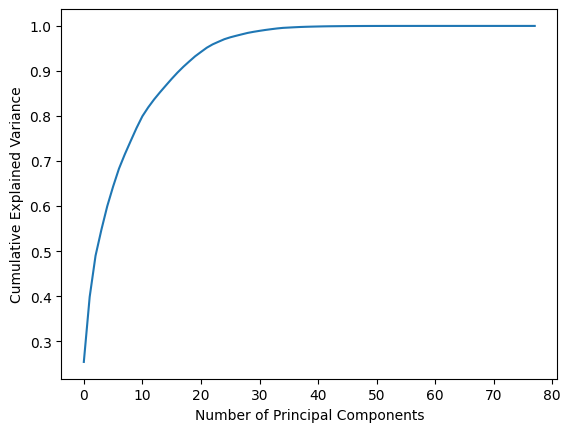

In [136]:
pca_test = PCA().fit(df_scaled)
plt.plot(np.cumsum(pca_test.explained_variance_ratio_))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

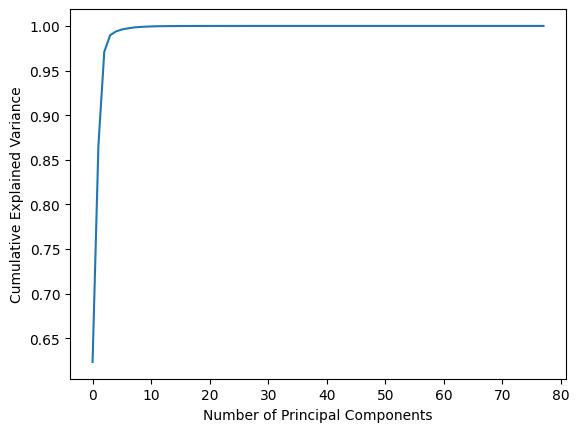

In [137]:
pca_test = PCA().fit(df_no_labels)
plt.plot(np.cumsum(pca_test.explained_variance_ratio_))
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [138]:
pca = PCA(
    n_components=dimensions_num_for_PCA
)

principal_components = pca.fit(
    df_no_labels
).transform(
    df_no_labels
)

principal_components

array([[-8.16580279e+06, -1.19915322e+06,  1.27263308e+05, ...,
        -8.93600581e+05, -2.96811663e+05, -5.98234593e+03],
       [-8.08590567e+06, -1.19861324e+06,  9.21736216e+04, ...,
        -8.99819189e+05, -2.96878115e+05, -5.81150453e+03],
       [-1.00194924e+07, -1.22629216e+06,  2.02487220e+05, ...,
         2.15507753e+05,  5.82407941e+04,  3.75222176e+04],
       ...,
       [-9.77881129e+06,  1.20711384e+05,  1.08402286e+05, ...,
         1.99889067e+05,  4.93926336e+04,  4.26804840e+04],
       [-9.80388112e+06, -4.42548507e+05,  1.21580327e+05, ...,
         1.96639141e+05,  4.85337246e+04,  3.96503044e+04],
       [-9.72175186e+06, -6.79955648e+05,  1.08244069e+05, ...,
         1.93449359e+05,  3.30418761e+04,  3.68706087e+04]],
      shape=(286096, 7))

In [139]:
principal_component_headings = get_PCA_feature_names(dimensions_num_for_PCA)

In [140]:
df_pc = pd.DataFrame(data = principal_components, columns = principal_component_headings)
df_pc

,Principal component 1,Principal component 2,Principal component 3,Principal component 4,Principal component 5,Principal component 6,Principal component 7
0,-8.165803e+06,-1.199153e+06,127263.307756,-231525.444244,-893600.580534,-296811.662984,-5982.345935
1,-8.085906e+06,-1.198613e+06,92173.621578,-222554.882115,-899819.189254,-296878.115459,-5811.504529
2,-1.001949e+07,-1.226292e+06,202487.219507,114026.034526,215507.753418,58240.794133,37522.217603
3,-8.104574e+06,-1.198907e+06,114579.819424,-232052.538819,-886792.249240,-309302.450961,-6391.775131
4,-1.001953e+07,-1.226232e+06,202496.514118,114079.976276,215668.219754,58255.708667,37616.209415
...,...,...,...,...,...,...,...
286091,-9.702691e+06,-6.754558e+05,108811.962532,113698.699726,192210.876425,27627.809010,36484.272722
286092,-9.338204e+06,-9.387585e+05,107612.275294,53678.418683,166703.000669,-86349.888528,14930.171400
286093,-9.778811e+06,1.207114e+05,108402.286219,123110.822316,199889.066997,49392.633591,42680.484006
286094,-9.803881e+06,-4.425485e+05,121580.327254,122251.188352,196639.141355,48533.724648,39650.304436


In [141]:
df_final = pd.concat([df_pc, df_labels], axis = 1)
# Scroll to the RHS end of dataframe to see attached label feature
df_final

,Principal component 1,Principal component 2,Principal component 3,Principal component 4,Principal component 5,Principal component 6,Principal component 7,label
0,-8.165803e+06,-1.199153e+06,127263.307756,-231525.444244,-893600.580534,-296811.662984,-5982.345935,BENIGN
1,-8.085906e+06,-1.198613e+06,92173.621578,-222554.882115,-899819.189254,-296878.115459,-5811.504529,BENIGN
2,-1.001949e+07,-1.226292e+06,202487.219507,114026.034526,215507.753418,58240.794133,37522.217603,BENIGN
3,-8.104574e+06,-1.198907e+06,114579.819424,-232052.538819,-886792.249240,-309302.450961,-6391.775131,BENIGN
4,-1.001953e+07,-1.226232e+06,202496.514118,114079.976276,215668.219754,58255.708667,37616.209415,BENIGN
...,...,...,...,...,...,...,...,...
286091,-9.702691e+06,-6.754558e+05,108811.962532,113698.699726,192210.876425,27627.809010,36484.272722,BENIGN
286092,-9.338204e+06,-9.387585e+05,107612.275294,53678.418683,166703.000669,-86349.888528,14930.171400,BENIGN
286093,-9.778811e+06,1.207114e+05,108402.286219,123110.822316,199889.066997,49392.633591,42680.484006,BENIGN
286094,-9.803881e+06,-4.425485e+05,121580.327254,122251.188352,196639.141355,48533.724648,39650.304436,BENIGN


In [142]:
lb = LabelBinarizer()
df_final['label'] = lb.fit_transform(df_final['label'])
df_final

,Principal component 1,Principal component 2,Principal component 3,Principal component 4,Principal component 5,Principal component 6,Principal component 7,label
0,-8.165803e+06,-1.199153e+06,127263.307756,-231525.444244,-893600.580534,-296811.662984,-5982.345935,0
1,-8.085906e+06,-1.198613e+06,92173.621578,-222554.882115,-899819.189254,-296878.115459,-5811.504529,0
2,-1.001949e+07,-1.226292e+06,202487.219507,114026.034526,215507.753418,58240.794133,37522.217603,0
3,-8.104574e+06,-1.198907e+06,114579.819424,-232052.538819,-886792.249240,-309302.450961,-6391.775131,0
4,-1.001953e+07,-1.226232e+06,202496.514118,114079.976276,215668.219754,58255.708667,37616.209415,0
...,...,...,...,...,...,...,...,...
286091,-9.702691e+06,-6.754558e+05,108811.962532,113698.699726,192210.876425,27627.809010,36484.272722,0
286092,-9.338204e+06,-9.387585e+05,107612.275294,53678.418683,166703.000669,-86349.888528,14930.171400,0
286093,-9.778811e+06,1.207114e+05,108402.286219,123110.822316,199889.066997,49392.633591,42680.484006,0
286094,-9.803881e+06,-4.425485e+05,121580.327254,122251.188352,196639.141355,48533.724648,39650.304436,0


In [143]:
print("Before LabelBinarizer: ", df_labels.unique())
print("After LabelBinarizer: ", df_final['label'].unique())

Before LabelBinarizer:  <ArrowStringArray>
['BENIGN', 'PortScan']
Length: 2, dtype: str
After LabelBinarizer:  [0 1]


In [ ]:
if len(df_final) > 30000:
    df_final = df_final.sample(n=30000, random_state=42).reset_index(drop=True)

X = df_final.drop(['label'], axis=1)
y = df_final['label']
y


0         0
1         0
2         0
3         0
4         0
         ..
286091    0
286092    0
286093    0
286094    0
286095    0
Name: label, Length: 286096, dtype: int64

In [145]:
skf = StratifiedKFold(n_splits=num_of_splits_for_skf, shuffle=False)
skf

StratifiedKFold(n_splits=10, random_state=None, shuffle=False)

In [146]:
for train_index, test_index in skf.split(X, y):

    X_train = X.iloc[train_index]
    X_test = X.iloc[test_index]

    y_train = y.iloc[train_index]
    y_test = y.iloc[test_index]

    reshaped_y_train = np.asarray(
        y_train
    ).reshape(-1, 1)

    reshaped_y_test = np.asarray(
        y_test
    ).reshape(-1, 1)

print(
    'X_train length:',
    len(X_train)
)

print(
    'y_train length:',
    len(y_train)
)

print(
    'X_test length:',
    len(X_test)
)

print(
    'y_test length:',
    len(y_test)
)

X_train length: 257487
y_train length: 257487
X_test length: 28609
y_test length: 28609


In [147]:
knn_model = KNeighborsClassifier(n_neighbors=5, weights='uniform',
                                    algorithm='auto', leaf_size=30,
                                    p=2, metric='minkowski',
                                    metric_params=None, n_jobs=None)

Classification report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     12729
           1       1.00      1.00      1.00     15880

    accuracy                           1.00     28609
   macro avg       1.00      1.00      1.00     28609
weighted avg       1.00      1.00      1.00     28609
 

Model accuracy=  99.65395504911042 %

Dataset labels:  <ArrowStringArray>
['BENIGN', 'PortScan']
Length: 2, dtype: str
Dataset numeric labels after encoding for model:  [0 1]


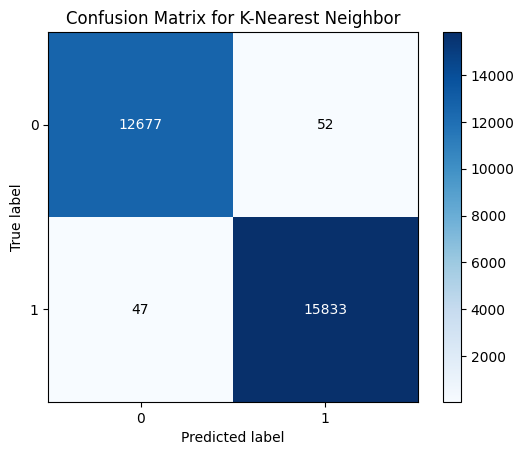

In [148]:
accuracy, X_train, X_test, y_train, pred_y = train_model_predict(knn_model, "K-Nearest Neighbor", X, y, skf)
print("Model accuracy= ", accuracy*100, "%\n")
print("Dataset labels: ", df_labels.unique())
print("Dataset numeric labels after encoding for model: ", df_final['label'].unique())

In [149]:
# Extracting the number of classes and labels from the label feature
class_num = len(df_final['label'].unique())
labels = df_final['label'].unique()
print("Number of classes: ", class_num)
print("Labels: ", labels)

Number of classes:  2
Labels:  [0 1]


In [150]:
X_train


,Principal component 1,Principal component 2,Principal component 3,Principal component 4,Principal component 5,Principal component 6,Principal component 7
0,-8.165803e+06,-1.199153e+06,1.272633e+05,-2.315254e+05,-893600.580534,-2.968117e+05,-5.982346e+03
1,-8.085906e+06,-1.198613e+06,9.217362e+04,-2.225549e+05,-899819.189254,-2.968781e+05,-5.811505e+03
2,-1.001949e+07,-1.226292e+06,2.024872e+05,1.140260e+05,215507.753418,5.824079e+04,3.752222e+04
3,-8.104574e+06,-1.198907e+06,1.145798e+05,-2.320525e+05,-886792.249240,-3.093025e+05,-6.391775e+03
4,-1.001953e+07,-1.226232e+06,2.024965e+05,1.140800e+05,215668.219754,5.825571e+04,3.761621e+04
...,...,...,...,...,...,...,...
264345,2.198678e+08,1.380216e+06,1.701027e+08,5.037324e+07,-351189.985288,3.080752e+06,-2.176100e+06
264346,-9.906154e+06,-1.223417e+06,2.222463e+05,1.001826e+05,118844.252902,2.512903e+04,1.045444e+02
264347,-9.974813e+06,-1.223502e+06,2.102830e+05,1.085742e+05,177375.336509,4.516016e+04,2.274868e+04
264348,-9.991084e+06,-1.218311e+06,2.086187e+05,1.100024e+05,191929.370539,4.893430e+04,3.011515e+04


In [151]:
# x1 = X_test[np.where(np.asarray(y_train).reshape(-1, 1).ravel() == labels[0])]
# X_train_L = X_train.iloc[np.where(y_train[:,1] == 1)]
X_train_L = X_train.loc[y_train == labels[0]]
X_test_L = X_test.loc[pred_y == labels[0]]
X_train_L

,Principal component 1,Principal component 2,Principal component 3,Principal component 4,Principal component 5,Principal component 6,Principal component 7
0,-8.165803e+06,-1.199153e+06,1.272633e+05,-2.315254e+05,-893600.580534,-2.968117e+05,-5.982346e+03
1,-8.085906e+06,-1.198613e+06,9.217362e+04,-2.225549e+05,-899819.189254,-2.968781e+05,-5.811505e+03
2,-1.001949e+07,-1.226292e+06,2.024872e+05,1.140260e+05,215507.753418,5.824079e+04,3.752222e+04
3,-8.104574e+06,-1.198907e+06,1.145798e+05,-2.320525e+05,-886792.249240,-3.093025e+05,-6.391775e+03
4,-1.001953e+07,-1.226232e+06,2.024965e+05,1.140800e+05,215668.219754,5.825571e+04,3.761621e+04
...,...,...,...,...,...,...,...
264345,2.198678e+08,1.380216e+06,1.701027e+08,5.037324e+07,-351189.985288,3.080752e+06,-2.176100e+06
264346,-9.906154e+06,-1.223417e+06,2.222463e+05,1.001826e+05,118844.252902,2.512903e+04,1.045444e+02
264347,-9.974813e+06,-1.223502e+06,2.102830e+05,1.085742e+05,177375.336509,4.516016e+04,2.274868e+04
264348,-9.991084e+06,-1.218311e+06,2.086187e+05,1.100024e+05,191929.370539,4.893430e+04,3.011515e+04


In [152]:
# x1 = X_test[np.where(np.asarray(y_train).reshape(-1, 1).ravel() == labels[0])]
# X_train_L = X_train.iloc[np.where(y_train[:,1] == 1)]
X_train_L = X_train.loc[y_train == labels[0]]
X_test_L = X_test.loc[pred_y == labels[0]]
X_train_L

,Principal component 1,Principal component 2,Principal component 3,Principal component 4,Principal component 5,Principal component 6,Principal component 7
0,-8.165803e+06,-1.199153e+06,1.272633e+05,-2.315254e+05,-893600.580534,-2.968117e+05,-5.982346e+03
1,-8.085906e+06,-1.198613e+06,9.217362e+04,-2.225549e+05,-899819.189254,-2.968781e+05,-5.811505e+03
2,-1.001949e+07,-1.226292e+06,2.024872e+05,1.140260e+05,215507.753418,5.824079e+04,3.752222e+04
3,-8.104574e+06,-1.198907e+06,1.145798e+05,-2.320525e+05,-886792.249240,-3.093025e+05,-6.391775e+03
4,-1.001953e+07,-1.226232e+06,2.024965e+05,1.140800e+05,215668.219754,5.825571e+04,3.761621e+04
...,...,...,...,...,...,...,...
264345,2.198678e+08,1.380216e+06,1.701027e+08,5.037324e+07,-351189.985288,3.080752e+06,-2.176100e+06
264346,-9.906154e+06,-1.223417e+06,2.222463e+05,1.001826e+05,118844.252902,2.512903e+04,1.045444e+02
264347,-9.974813e+06,-1.223502e+06,2.102830e+05,1.085742e+05,177375.336509,4.516016e+04,2.274868e+04
264348,-9.991084e+06,-1.218311e+06,2.086187e+05,1.100024e+05,191929.370539,4.893430e+04,3.011515e+04


In [153]:
num_of_features = len(X_train_L.columns)
num_of_features

7

In [154]:
CVM_distances = np.zeros(num_of_features)
Anderson_Darling_distances = np.zeros(num_of_features)
Kolmogorov_Smirnov_distances = np.zeros(num_of_features)
Kuiper_distances = np.zeros(num_of_features)
Wasserstein_distances = np.zeros(num_of_features)
DTS_distances = np.zeros(num_of_features)

for i in range(0, num_of_features):
    # iloc[:, i] allows selection of the ith feature in the Pandas dataframe 
    CVM_distances[i] = Cramer_Von_Mises_Dist(X_train_L.iloc[:, i], X_test_L.iloc[:, i])
    Anderson_Darling_distances[i] = Anderson_Darling_Dist(X_train_L.iloc[:, i], X_test_L.iloc[:, i])
    Kolmogorov_Smirnov_distances[i] = Kolmogorov_Smirnov_Dist(X_train_L.iloc[:, i], X_test_L.iloc[:, i])
    Kuiper_distances[i] = Kuiper_Dist(X_train_L.iloc[:, i], X_test_L.iloc[:, i])
    Wasserstein_distances[i] = Wasserstein_Dist(X_train_L.iloc[:, i], X_test_L.iloc[:, i])
    DTS_distances[i] = DTS_Dist(X_train_L.iloc[:, i], X_test_L.iloc[:, i])
    
print(" Cramer Von Mises distances: ", CVM_distances)
print("\n Anderson Darling distances: ", Anderson_Darling_distances)
print("\n Kolmogorov Smirnov distances: ", Kolmogorov_Smirnov_distances)
print("\n Kuiper distances: ", Kuiper_distances)
print("\n Wasserstein distances: ", Wasserstein_distances)
print("\n DTS distances: ", DTS_distances)

 Cramer Von Mises distances:  [2145.09062898 3554.18708617 2795.4801054  1583.62372238 1961.45443743
 4157.49299455 3448.61466512]

 Anderson Darling distances:  [15.67865018 23.73507125 18.74274938 11.34764942 12.67932826 26.91375291
 22.30160905]

 Kolmogorov Smirnov distances:  [0.03326813 0.06777357 0.04982426 0.03216095 0.03921818 0.06471298
 0.06118417]

 Kuiper distances:  [0.06600481 0.08118545 0.06521067 0.04751724 0.05236605 0.06570585
 0.06866847]

 Wasserstein distances:  [3632561.56936993  697564.99629972 1409309.94123757  502971.35604457
  196334.6914328   141436.12765719  100784.48478599]

 DTS distances:  [39541.56024532 41304.46940677 28045.40926569 12347.52975742
 10181.14866786  7479.79698277  8566.20205983]


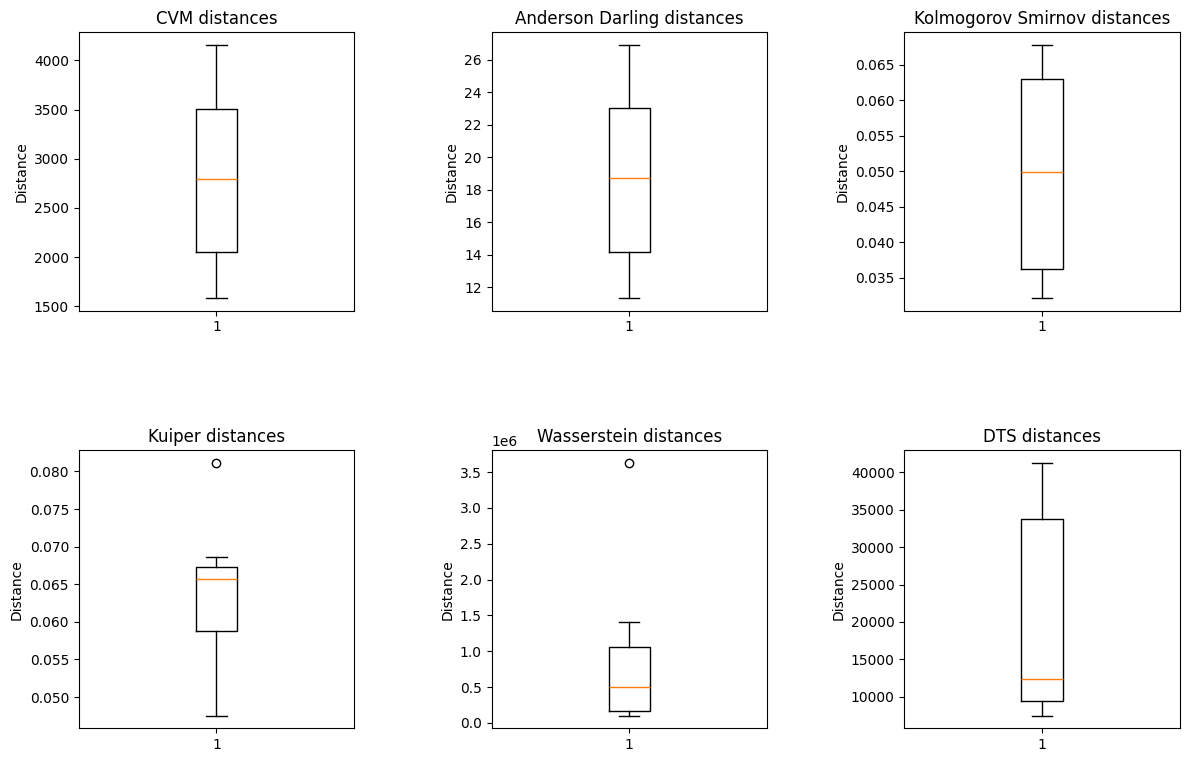

In [155]:
fig, axs = plt.subplots(2, 3)

axs[0, 0].boxplot(CVM_distances)
axs[0, 0].set_title('CVM distances')
axs[0, 0].set_ylabel("Distance")

axs[0, 1].boxplot(Anderson_Darling_distances)
axs[0, 1].set_title('Anderson Darling distances')
axs[0, 1].set_ylabel("Distance")

axs[0, 2].boxplot(Kolmogorov_Smirnov_distances)
axs[0, 2].set_title('Kolmogorov Smirnov distances')
axs[0, 2].set_ylabel("Distance")

axs[1, 0].boxplot(Kuiper_distances)
axs[1, 0].set_title("Kuiper distances")
axs[1, 0].set_ylabel("Distance")

axs[1, 1].boxplot(Wasserstein_distances)
axs[1, 1].set_title("Wasserstein distances")
axs[1, 1].set_ylabel("Distance")

axs[1, 2].boxplot(DTS_distances)
axs[1, 2].set_title("DTS distances")
axs[1, 2].set_ylabel("Distance")

fig.subplots_adjust(left=0.08, right=1.8, bottom=0.05, top=1.5, hspace=0.5, wspace=0.5)

plt.show()

In [156]:
df_final

,Principal component 1,Principal component 2,Principal component 3,Principal component 4,Principal component 5,Principal component 6,Principal component 7,label
0,-8.165803e+06,-1.199153e+06,127263.307756,-231525.444244,-893600.580534,-296811.662984,-5982.345935,0
1,-8.085906e+06,-1.198613e+06,92173.621578,-222554.882115,-899819.189254,-296878.115459,-5811.504529,0
2,-1.001949e+07,-1.226292e+06,202487.219507,114026.034526,215507.753418,58240.794133,37522.217603,0
3,-8.104574e+06,-1.198907e+06,114579.819424,-232052.538819,-886792.249240,-309302.450961,-6391.775131,0
4,-1.001953e+07,-1.226232e+06,202496.514118,114079.976276,215668.219754,58255.708667,37616.209415,0
...,...,...,...,...,...,...,...,...
286091,-9.702691e+06,-6.754558e+05,108811.962532,113698.699726,192210.876425,27627.809010,36484.272722,0
286092,-9.338204e+06,-9.387585e+05,107612.275294,53678.418683,166703.000669,-86349.888528,14930.171400,0
286093,-9.778811e+06,1.207114e+05,108402.286219,123110.822316,199889.066997,49392.633591,42680.484006,0
286094,-9.803881e+06,-4.425485e+05,121580.327254,122251.188352,196639.141355,48533.724648,39650.304436,0


In [157]:
results_column_names = [
    'Accuracy',
    'Anderson_Darling_dist',
    'CVM_dist',
    'DTS_dist',
    'Kolmogorov_Smirnov_dist',
    'Kuiper_dist',
    'Wasserstein_dist'
]

df_results = pd.DataFrame(
    columns=results_column_names
)

df_results

,Accuracy,Anderson_Darling_dist,CVM_dist,DTS_dist,Kolmogorov_Smirnov_dist,Kuiper_dist,Wasserstein_dist


In [158]:
number_of_permutations = 100

In [159]:
from tqdm import tqdm
from sklearn.model_selection import train_test_split

labels = df_final['label'].unique()

number_of_classes = len(
    df_final['label'].unique()
)

list_of_lists_results = [
    [] for i in range(number_of_classes)
]

for current_permutation in tqdm(
    range(number_of_permutations)
):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.33,
        random_state=114
    )

    pred_y, accuracy = train_and_predict_Neural_Network_MLP_model(
        X_train,
        X_test,
        y_train,
        y_test
    )

    for current_label in range(number_of_classes):

        X_train_loc_for_label, X_test_loc_for_label = get_X_train_and_test_data_for_given_label(
            labels,
            current_label,
            pred_y,
            X_train,
            X_test,
            y_train,
            y_test
        )

        dict_result_row = get_statistical_dist_measures_for_class_result(
            accuracy,
            X_train_loc_for_label,
            X_test_loc_for_label
        )

        list_of_lists_results[current_label].append(
            dict_result_row
        )

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [54:51<00:00, 32.92s/it]


In [160]:
result_dataframes = []

for dict_result_list in list_of_lists_results:
    result_dataframes.append(pd.DataFrame(dict_result_list, columns = results_column_names))

In [161]:
result_dataframes[0].head()

,Accuracy,Anderson_Darling_dist,CVM_dist,DTS_dist,Kolmogorov_Smirnov_dist,Kuiper_dist,Wasserstein_dist
0,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07
1,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07
2,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07
3,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07
4,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07


In [162]:
!pip install openpyxl

In [163]:
result_dataframes[0].to_excel("Class0.xlsx")

In [165]:
# Print second dataframe result table, for class 1
result_dataframes[1].head(8)

,Accuracy,Anderson_Darling_dist,CVM_dist,DTS_dist,Kolmogorov_Smirnov_dist,Kuiper_dist,Wasserstein_dist
0,0.632441,105.800218,17017.806239,22054.391474,0.28442,0.340719,499112.029097
1,0.632441,105.800218,17017.806239,22054.391474,0.28442,0.340719,499112.029097
2,0.632441,105.800218,17017.806239,22054.391474,0.28442,0.340719,499112.029097
3,0.632441,105.800218,17017.806239,22054.391474,0.28442,0.340719,499112.029097
4,0.632441,105.800218,17017.806239,22054.391474,0.28442,0.340719,499112.029097
5,0.632441,105.800218,17017.806239,22054.391474,0.28442,0.340719,499112.029097
6,0.632441,105.800218,17017.806239,22054.391474,0.28442,0.340719,499112.029097
7,0.632441,105.800218,17017.806239,22054.391474,0.28442,0.340719,499112.029097


In [166]:
result_dataframes[1].to_excel("Class1.xlsx")

In [167]:
concatenated = get_concatenated_results_holding_all_classes_results(number_of_classes, result_dataframes)
concatenated.head(110)

,Accuracy,Anderson_Darling_dist,CVM_dist,DTS_dist,Kolmogorov_Smirnov_dist,Kuiper_dist,Wasserstein_dist,dataset
0,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07,class0
1,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07,class0
2,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07,class0
3,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07,class0
4,0.632441,155.930379,18337.289193,313266.935056,0.449169,0.646932,1.962496e+07,class0
...,...,...,...,...,...,...,...,...
105,0.632441,105.800218,17017.806239,22054.391474,0.284420,0.340719,4.991120e+05,class1
106,0.632441,105.800218,17017.806239,22054.391474,0.284420,0.340719,4.991120e+05,class1
107,0.632441,105.800218,17017.806239,22054.391474,0.284420,0.340719,4.991120e+05,class1
108,0.632441,105.800218,17017.806239,22054.391474,0.284420,0.340719,4.991120e+05,class1


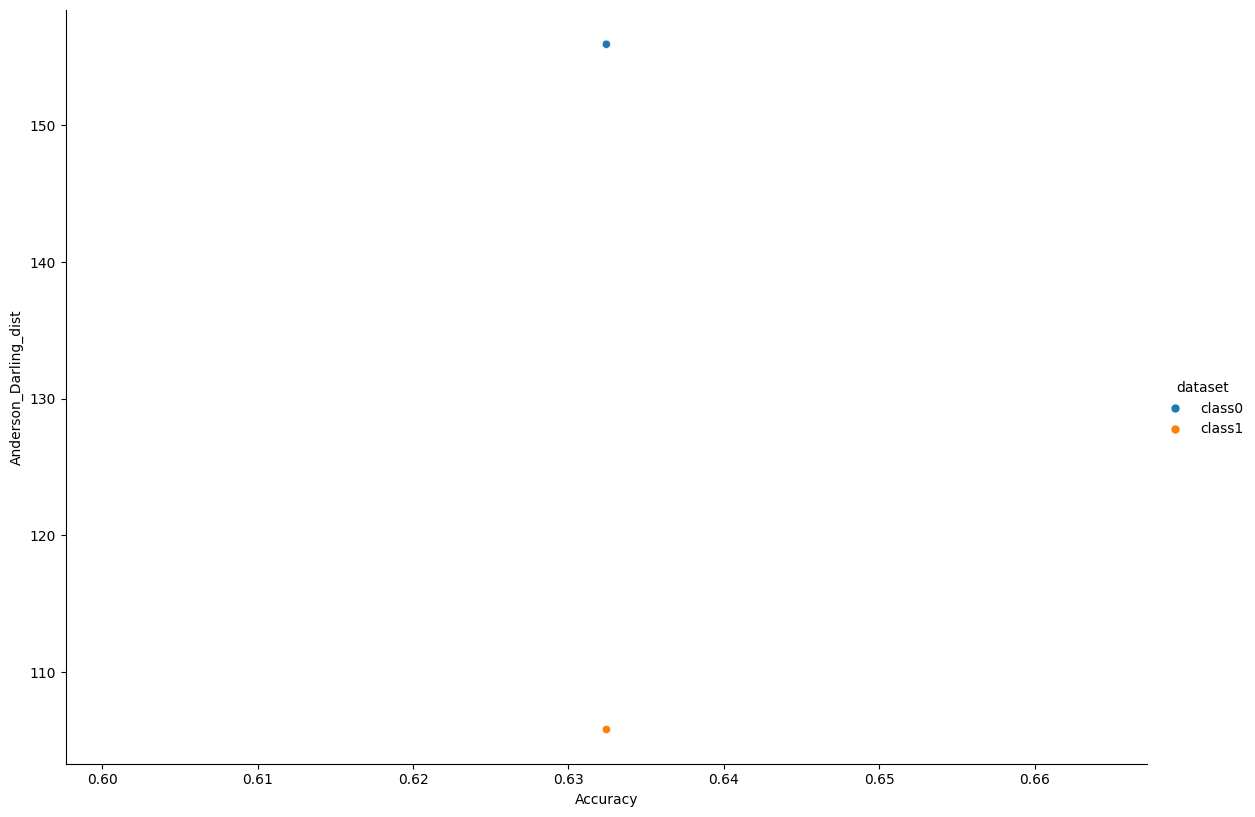

In [ ]:
sns.relplot(data=concatenated, x='Accuracy', y='Anderson_Darling_dist',
                hue='dataset', height=8.27, aspect=11.7/8.27)
plt.show()

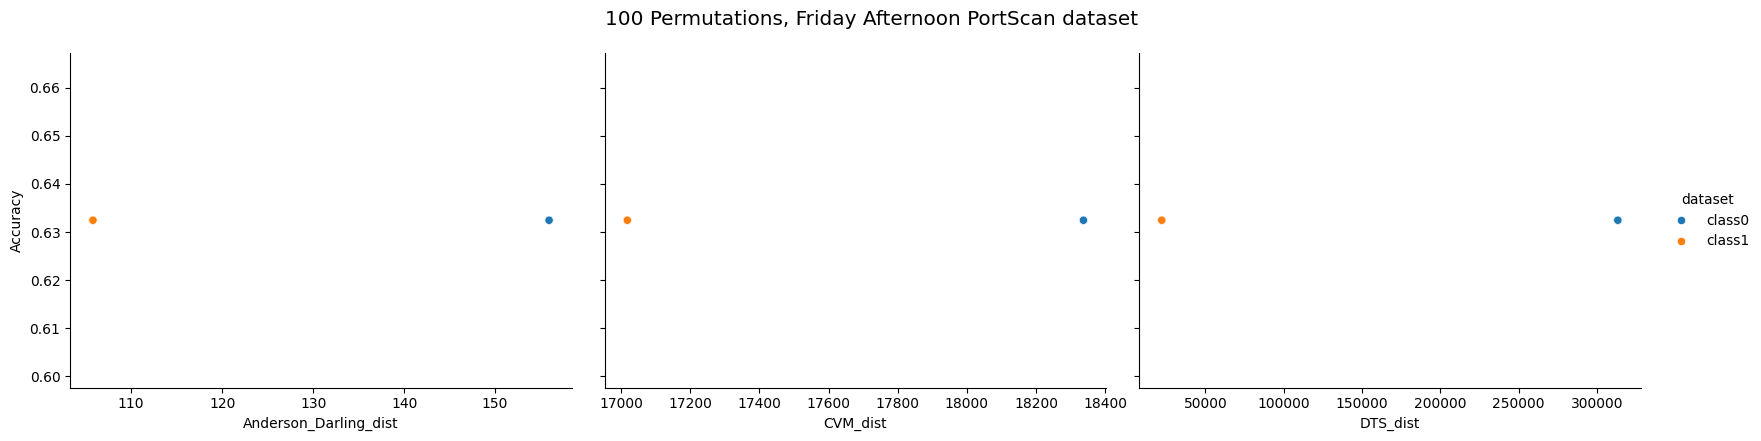

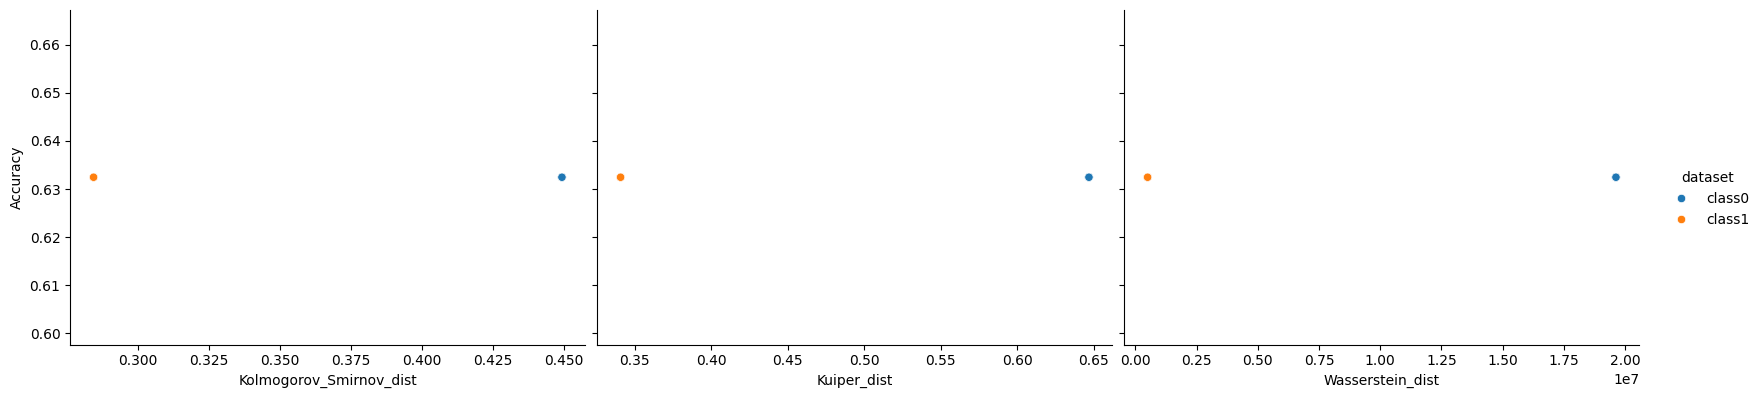

In [ ]:
plot_title = "100 Permutations, Friday Afternoon PortScan dataset"

g = sns.pairplot(
    data=concatenated,
    y_vars=['Accuracy'],
    x_vars=['Anderson_Darling_dist', 'CVM_dist','DTS_dist'],
    hue='dataset',
    height=4,
    aspect=1.4
)
g.fig.suptitle(plot_title, y=1.08, fontsize='x-large')

sns.pairplot(
    data=concatenated,
    y_vars=['Accuracy'],
    x_vars=['Kolmogorov_Smirnov_dist','Kuiper_dist', 'Wasserstein_dist'],
    hue='dataset',
    height=4,
    aspect=1.4
)
plt.show()